## Importar las Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración para gráficos más nítidos
plt.rcParams["figure.figsize"] = (8, 5)
plt.style.use("ggplot")


# 1. Cargar del dataset Inventario
Cargar los datos de inventario desde la hoja de cálculo Excel.

In [2]:
inventario = pd.read_excel("inventario.xlsx")

# 2. Inspección de los datos.

In [3]:
print("\n--- Visualización previa de las primeras 5 filas ---")
inventario.head()


--- Visualización previa de las primeras 5 filas ---


,ID_PRODUCTO,PRODUCTO,CATEGORIA,MARCA,STOCK_ACTUAL,PRECIO_UNITARIO,STOCK_MINIMO,ESTADO_STOCK
0,P001,Notebook Lenovo,Informática,Lenovo,25,850000,8,Disponible
1,P002,Monitor Samsung 24,Monitores,Samsung,18,220000,6,Disponible
2,P003,Mouse inalámbrico,Periféricos,Logitech,45,18500,10,Disponible
3,P004,Auriculares Bluetooth,Audio,JBL,30,45000,8,Disponible
4,P005,Teclado mecánico,Periféricos,Redragon,22,72000,6,Disponible


In [4]:
print("\n--- Información general ---")
inventario.info()


--- Información general ---
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID_PRODUCTO      10 non-null     str  
 1   PRODUCTO         10 non-null     str  
 2   CATEGORIA        10 non-null     str  
 3   MARCA            10 non-null     str  
 4   STOCK_ACTUAL     10 non-null     int64
 5   PRECIO_UNITARIO  10 non-null     int64
 6   STOCK_MINIMO     10 non-null     int64
 7   ESTADO_STOCK     10 non-null     str  
dtypes: int64(3), str(5)
memory usage: 1.2 KB


In [5]:
print("\n--- Estadísticas descriptivas — variables numéricas ---")
inventario.describe()
#print(inventario.describe())


--- Estadísticas descriptivas — variables numéricas ---


,STOCK_ACTUAL,PRECIO_UNITARIO,STOCK_MINIMO
count,10.000000,10.000000,10.000000
mean,19.800000,198050.000000,6.000000
std,11.370527,246065.985956,2.108185
min,7.000000,18500.000000,3.000000
25%,12.500000,61500.000000,5.000000
50%,17.000000,111000.000000,5.500000
75%,24.250000,211250.000000,7.500000
max,45.000000,850000.000000,10.000000


### El ejercicio pide calcular el promedio de stock disponible para todos los productos.

In [6]:
promedio_stock = inventario["STOCK_ACTUAL"].mean()

print(f"Promedio de stock disponible: {promedio_stock:.2f} unidades")

Promedio de stock disponible: 19.80 unidades


# 3. Visualización Univariada

## Histogramas y Boxplots para observar la distribución y detectar posibles outliers.

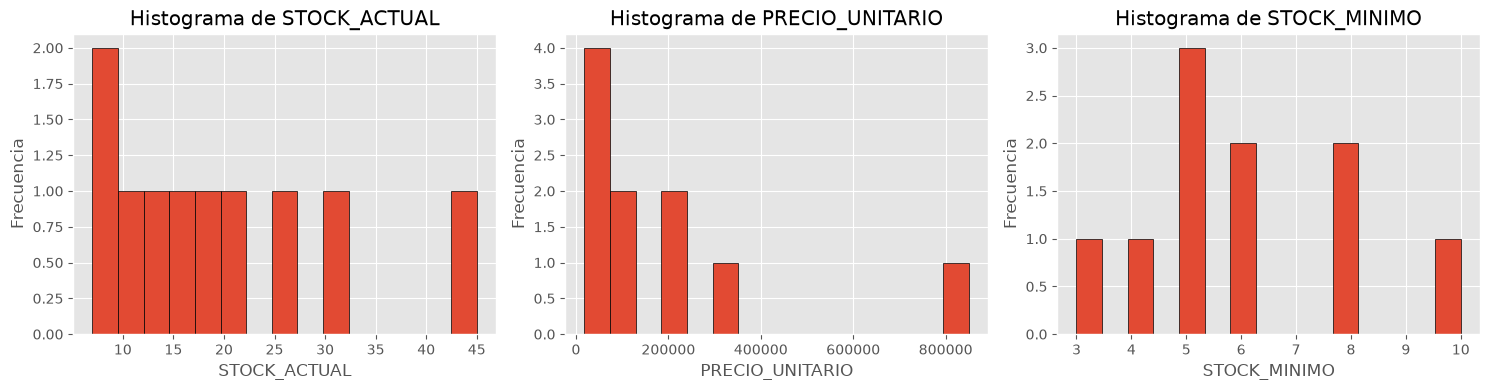

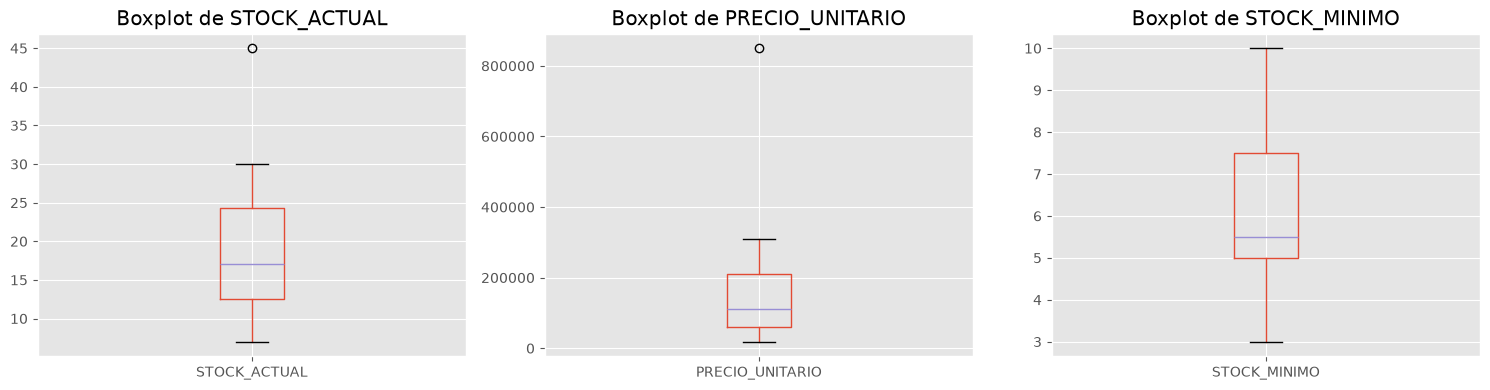

In [7]:
# Seleccionamos solo columnas numéricas
numericas = ["STOCK_ACTUAL", "PRECIO_UNITARIO", "STOCK_MINIMO"]

# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, columna in zip(axes, numericas):
    inventario[columna].hist(bins=15, ax=ax, edgecolor="black")
    ax.set_title(f"Histograma de {columna}")
    ax.set_xlabel(columna)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, columna in zip(axes, numericas):
    inventario.boxplot(column=columna, ax=ax)
    ax.set_title(f"Boxplot de {columna}")

plt.tight_layout()
plt.show()

## Creación de diferentes tipos de gráficos, se busca identificar patrones, distribuciones, relaciones y posibles outliers en los datos.

### Gráfico 1 — Cantidad de productos por CATEGORIA
Sirve para ver patrones de composición del catálogo

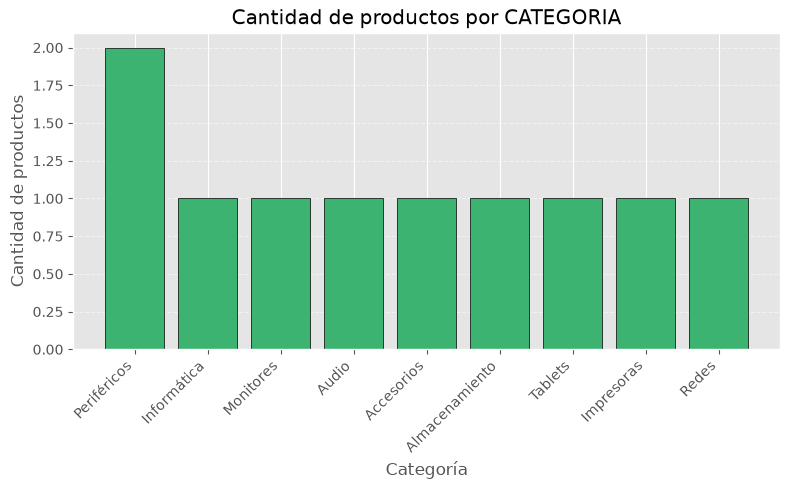

In [8]:
cat_counts = inventario['CATEGORIA'].value_counts()

plt.bar(cat_counts.index, cat_counts.values, color='mediumseagreen', edgecolor='black')
plt.title('Cantidad de productos por CATEGORIA')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de productos')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Gráfico 2 — Distribución por MARCA 

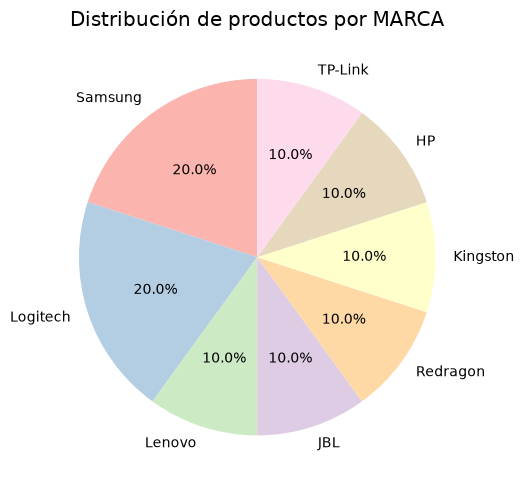

In [9]:
marca_counts = inventario['MARCA'].value_counts()

plt.pie(marca_counts.values, labels=marca_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=plt.cm.Pastel1.colors)
plt.title('Distribución de productos por MARCA')
plt.tight_layout()
plt.show()

### Gráfico 3 — STOCK_ACTUAL por CATEGORIA — Barras agrupadas
Sirve para comparar qué categorías tienen más stock.

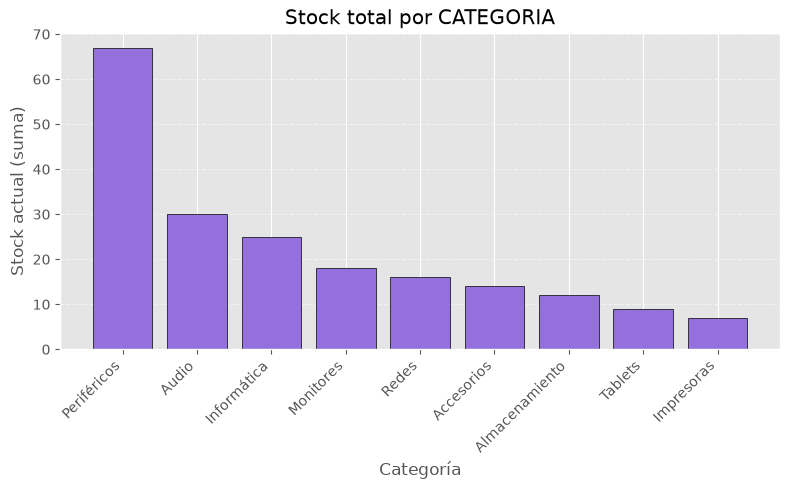

In [10]:
stock_por_cat = inventario.groupby('CATEGORIA')['STOCK_ACTUAL'].sum().sort_values(ascending=False)

plt.bar(stock_por_cat.index, stock_por_cat.values, color='mediumpurple', edgecolor='black')
plt.title('Stock total por CATEGORIA')
plt.xlabel('Categoría')
plt.ylabel('Stock actual (suma)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Relaciones entre variables - Matriz de Correlación


--- Correlaciones ---
                 STOCK_ACTUAL  PRECIO_UNITARIO  STOCK_MINIMO
STOCK_ACTUAL         1.000000        -0.090878      0.968756
PRECIO_UNITARIO     -0.090878         1.000000      0.087603
STOCK_MINIMO         0.968756         0.087603      1.000000


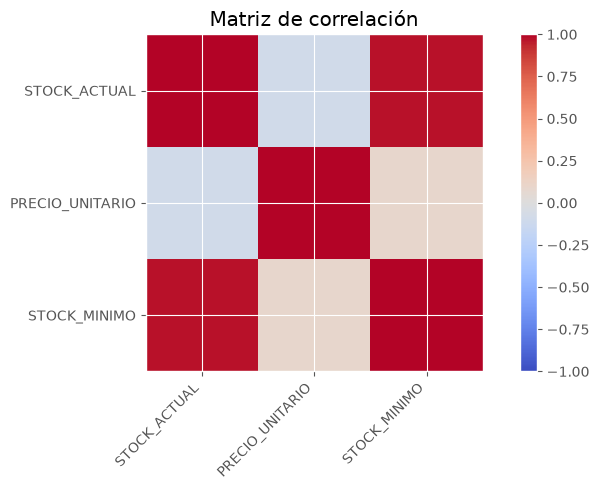

In [11]:
# Matriz de correlación
print("\n--- Correlaciones ---")
numericas = ['STOCK_ACTUAL', 'PRECIO_UNITARIO', 'STOCK_MINIMO']
corr = inventario[numericas].corr()
print(corr)

#plt.matshow(datos.corr(), cmap="coolwarm")
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

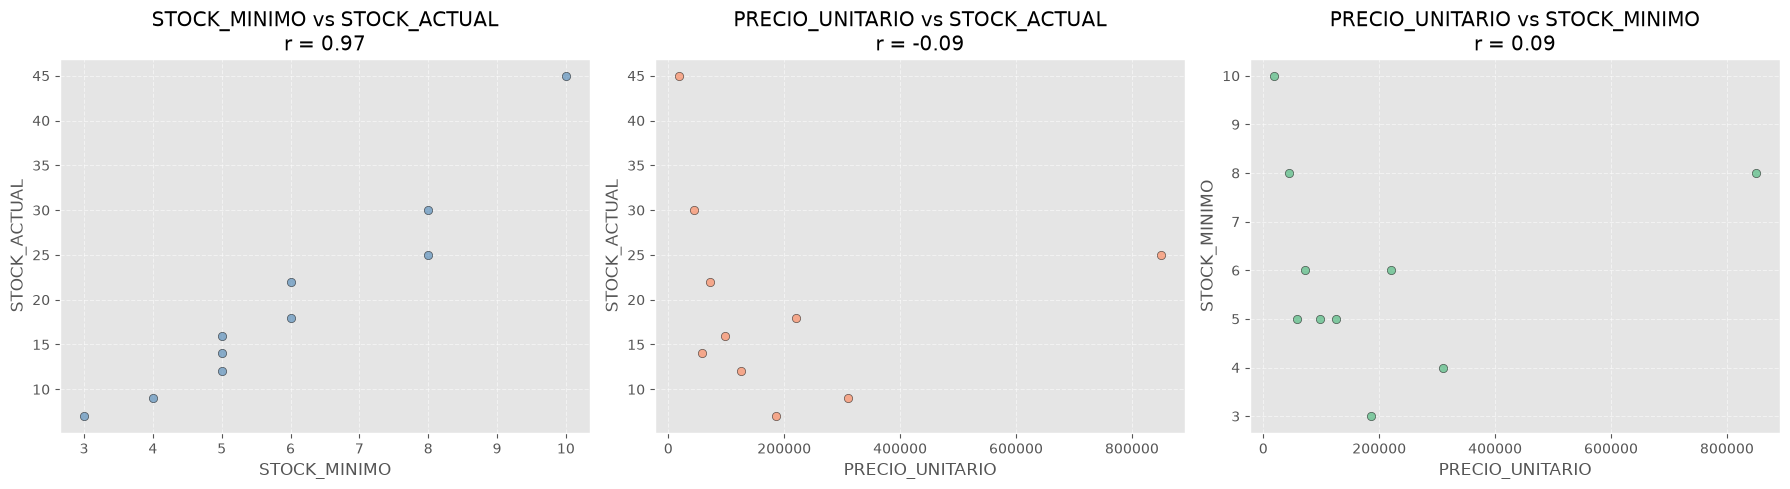

In [12]:
# Scatterplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pares = [
    ('STOCK_MINIMO', 'STOCK_ACTUAL', 'steelblue'),
    ('PRECIO_UNITARIO', 'STOCK_ACTUAL', 'coral'),
    ('PRECIO_UNITARIO', 'STOCK_MINIMO', 'mediumseagreen')
]

for ax, (x, y, color) in zip(axes, pares):
    ax.scatter(inventario[x], inventario[y], alpha=0.6, color=color, edgecolor='k')
    r = corr.loc[x, y]
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}\nr = {r:.2f}')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 5. Identificación de Outliers con regla IQR

In [13]:
Q1 = inventario["STOCK_ACTUAL"].quantile(0.25)
Q3 = inventario["STOCK_ACTUAL"].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

outliers = inventario[(inventario["STOCK_ACTUAL"] < Q1 - 1.5*IQR) | (inventario["STOCK_ACTUAL"] > Q3 + 1.5*IQR)]

print(f"\nCantidad de outliers en Stock_Actual: {len(outliers)}")
print(outliers)

Q1 = 12.5
Q3 = 24.25
IQR = 11.75

Cantidad de outliers en Stock_Actual: 1
  ID_PRODUCTO           PRODUCTO    CATEGORIA     MARCA  STOCK_ACTUAL  \
2        P003  Mouse inalámbrico  Periféricos  Logitech            45   

   PRECIO_UNITARIO  STOCK_MINIMO ESTADO_STOCK  
2            18500            10   Disponible  


In [14]:
Q1 = inventario['PRECIO_UNITARIO'].quantile(0.25)
Q3 = inventario['PRECIO_UNITARIO'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

outliers = inventario[(inventario['PRECIO_UNITARIO'] < Q1 - 1.5*IQR) | (inventario['PRECIO_UNITARIO'] > Q3 + 1.5*IQR)]

print(f"\nCantidad de outliers en Precio Unitario: {len(outliers)}")
print(outliers)

Q1 = 61500.0
Q3 = 211250.0
IQR = 149750.0

Cantidad de outliers en Precio Unitario: 1
  ID_PRODUCTO         PRODUCTO    CATEGORIA   MARCA  STOCK_ACTUAL  \
0        P001  Notebook Lenovo  Informática  Lenovo            25   

   PRECIO_UNITARIO  STOCK_MINIMO ESTADO_STOCK  
0           850000             8   Disponible  


In [15]:
print (inventario)

  ID_PRODUCTO                PRODUCTO       CATEGORIA     MARCA  STOCK_ACTUAL  \
0        P001         Notebook Lenovo     Informática    Lenovo            25   
1        P002      Monitor Samsung 24       Monitores   Samsung            18   
2        P003       Mouse inalámbrico     Periféricos  Logitech            45   
3        P004   Auriculares Bluetooth           Audio       JBL            30   
4        P005        Teclado mecánico     Periféricos  Redragon            22   
5        P006               Webcam HD      Accesorios  Logitech            14   
6        P007           Disco SSD 1TB  Almacenamiento  Kingston            12   
7        P008      Tablet 10 pulgadas         Tablets   Samsung             9   
8        P009  Impresora multifunción      Impresoras        HP             7   
9        P010           Router WiFi 6           Redes   TP-Link            16   

   PRECIO_UNITARIO  STOCK_MINIMO ESTADO_STOCK  
0           850000             8   Disponible  
1           